# Algorithmic Trading: Build a Momentum Strategy in Python
Digital Hub Insights LLC.

December 2025

Version: 3.0

Taught by: Cordell L. Tanny, CFA, FRM, FDP

Learn more about us: [digitalhub-labs.com](https://)


---



## Notebook 1: Analyzing Lookback and Holding Periods
Before implementing any trading strategy, it's critical to test the core theory behind it. This notebook validates the principle of momentum by analyzing historical data to see if past performance is a reliable indicator of future returns.

- We will group our universe of ETFs into deciles (10 groups) based on their past returns over various "lookback periods" (e.g., the last 12 months).

- The goal is to prove that the top-performing deciles consistently outperform the bottom-performing deciles. This academic-style research gives us confidence that the momentum effect is persistent and not just random chance.

- We will calculate returns over multiple lookback and forward-holding periods, then visualize the results in heatmaps and bar charts to identify the strongest and most consistent trends.







---
## Imports
- This cell installs and imports the necessary Python libraries for our analysis.

- We need specific tools for data manipulation `pandas`, numerical operations `numpy`, data visualization`matplotlib`, `seaborn`, and accessing our custom functions `functions` (please see the lecture videos that explain the `functions.py` file.

- We use pip to install any missing packages and standard import statements to make the libraries available in our notebook.



In [1]:
#!uv add -q pandas_market_calendars
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from momentum_trading.core import functions as fn
from dotenv import load_dotenv
import os


_ = load_dotenv()  

sns.set_theme()
# API Keys - set to None if not available
# The function will automatically fall back to available sources
try:
    fmp_api_key = os.environ['FMP_API_KEY']
except:
    fmp_api_key = None

try:
    eodhd_api_key =  os.environ['EOHD_API_KEY']  # Use 'EOD' not 'EODHD'
except:
    eodhd_api_key = None

# Verify the key was retrieved
print(f"FMP API key loaded: {fmp_api_key is not None}")
print(f"EODHD API key loaded: {eodhd_api_key is not None}")

FMP API key loaded: True
EODHD API key loaded: False


---
## Creating the Asset Universe
To test our theory, we need a broad and diverse set of assets. This code block defines our investment universe by creating dictionaries for different categories of Exchange-Traded Funds (ETFs).

- **Equity ETFs**: This is our largest group, covering various segments of the stock market, from broad indexes like VTI to specific sectors like XLE (Energy).

- **Fixed Income ETFs**: This group includes bond funds with different maturities and credit qualities, such as TLT (long-term treasuries) and HYG (high-yield corporate bonds).

- **Alternative/Commodity ETFs**: This category provides exposure to assets outside of stocks and bonds, like GLD (Gold) and DBC (Commodities).

Finally, we combine these groups into a single master list of tickers. Using a wide variety of assets makes our research more robust by showing that the momentum effect is not confined to a single market segment.


In [2]:
equity_etfs = {
    "QQQ": "Invesco QQQ Trust",
    "VTI": "Vanguard Total Stock Market ETF",
    "VYM": "Vanguard High Dividend Yield ETF",
    "IWM": "iShares Russell 2000 ETF",
    "SMDV": "ProShares Russell 2000 Dividend Growers",
    "SPYG": "SPDR Portfolio S&P 500 Growth ETF",
    "IWF": "iShares Russell 1000 Growth ETF",
    "VO": "Vanguard Mid-Cap ETF",
    "VBR": "Vanguard Small-Cap Value ETF",
    "VOE": "Vanguard Mid-Cap Value ETF",
    "SPGP": "Invesco S&P 500 GARP ETF",
    "REGL": "S&P MidCap 400 Dividend Aristocrats ETF",
    "IWV": "iShares Russell 3000 ETF",
    "XLF": "Financial Select Sector SPDR Fund",
    "XLE": "Energy Select Sector SPDR Fund",
    "XLK": "Technology Select Sector SPDR Fund",
    "XLV": "Health Care Select Sector SPDR Fund",
    "XLY": "Consumer Discretionary Select Sector SPDR Fund",
    "XLI": "Industrial Select Sector SPDR Fund",
    "XLP": "Consumer Staples Select Sector SPDR Fund",
    "XLU": "Utilities Select Sector SPDR Fund",
    "XLC": "Communication Services Select Sector SPDR Fund",
    "SOXX": "iShares Semiconductor ETF",
    "MOAT": "VanEck Morningstar Wide Moat ETF",
    "ARKK": "ARK Innovation ETF",
    "ARKG": "ARK Genomic Revolution ETF",
    "ARKW": "ARK Next Generation Internet ETF",
    "SDY": "SPDR S&P Dividend ETF",
    "USMV": "iShares Edge MSCI Min Vol USA ETF",
    "HDV": "iShares Core High Dividend ETF",
    "DIA": "SPDR Dow Jones Industrial Average ETF Trust",
    "FDN": "First Trust Dow Jones Internet Index Fund",
    "VIG": "Vanguard Dividend Appreciation ETF",
    "FPX": "First Trust US Equity Opportunities ETF",
    "ITB": "iShares U.S. Home Construction ETF",
    "ITA": "iShares U.S. Aerospace & Defense ETF",
    "DES": "WisdomTree U.S. SmallCap Dividend Fund",
    "XMLV": "Invesco S&P MidCap Low Volatility ETF",
    "SPY": "SPDR S&P 500 ETF Trust",
    "QTUM": "Defiance Quantum ETF",
}

# Fixed Income ETFs - Treasury, Corporate, and High Yield bonds
fixed_income_etfs = {
    "TLT": "iShares 20+ Year Treasury Bond ETF",
    "IEF": "iShares 7-10 Year Treasury Bond ETF",
    "SHY": "iShares 1-3 Year Treasury Bond ETF",
    "BIL": "SPDR Bloomberg 1-3 Month T-Bill ETF",
    "AGG": "iShares Core U.S. Aggregate Bond ETF",
    "LQD": "iShares iBoxx $ Investment Grade Corporate Bond ETF",
    "HYG": "iShares iBoxx $ High Yield Corporate Bond ETF",
    "MBB": "iShares MBS ETF",
    "PFF": "iShares Preferred and Income Securities ETF",
}

# Alternative/Commodity ETFs - Gold, Silver, Commodities, etc.
other_etfs = {
    "GLD": "SPDR Gold Shares",
    "SLV": "iShares Silver Trust",
    "DBC": "Invesco DB Commodity Index Tracking Fund",
    "USO": "United States Oil Fund",
    "PICK": "ishares MSCI Global Metals & Mining Producers ETF",
    "UUP": "Invesco DB US Dollar Index Bullish Fund",
    "GDX": "VanEck Vectors Gold Miners ETF",
    "GDXJ": "VanEck Vectors Junior Gold Miners ETF",
    "DBA": "Invesco DB Agriculture Fund",
}

# Combine all tickers for data loading
tickers = list(equity_etfs.keys()) + list(fixed_income_etfs.keys()) + list(other_etfs.keys())

## Downloading and Preparing Price Data

With our universe defined, the next step is to retrieve the historical price data for every ETF. This data will be the raw material for our entire analysis.

- We use our custom `get_bulk_prices` function to download daily price data for all tickers from our start date of January 1, 2005, through August 31, 2025. This long timeframe ensures our results are statistically significant.

- Since our strategy operates on a monthly cycle, we then resample the daily data to get the last price for each month (`resample('ME').last()`). This simplifies our calculations and aligns the data with our monthly decision-making process.

In [3]:
# Download prices for all ETFs
start_date = '2005-01-01'
end_date = '2026-06-30'
# Auto-fallback: tries FMP → EODHD → Yahoo Finance
# Or specify source='FMP', source='EOD', or source='yf' to use a specific source
df_prices = fn.get_bulk_prices(
    tickers,
    start_date,
    end_date,
    fmp_api_key=fmp_api_key,
    eodhd_api_key=eodhd_api_key,
    # source='yf'
)
df_prices = df_prices.resample('ME').last()

Determining best data source using QQQ...
Data retrieved from yf for QQQ
Using yf for all tickers
Data retrieved from yf for QQQ
Data retrieved from yf for VTI
Data retrieved from yf for VYM
Data retrieved from yf for IWM
Data retrieved from yf for SMDV
Data retrieved from yf for SPYG
Data retrieved from yf for IWF
Data retrieved from yf for VO
Data retrieved from yf for VBR
Data retrieved from yf for VOE
Data retrieved from yf for SPGP
Data retrieved from yf for REGL
Data retrieved from yf for IWV
Data retrieved from yf for XLF
Data retrieved from yf for XLE
Data retrieved from yf for XLK
Data retrieved from yf for XLV
Data retrieved from yf for XLY
Data retrieved from yf for XLI
Data retrieved from yf for XLP
Data retrieved from yf for XLU
Data retrieved from yf for XLC
Data retrieved from yf for SOXX
Data retrieved from yf for MOAT
Data retrieved from yf for ARKK
Data retrieved from yf for ARKG
Data retrieved from yf for ARKW
Data retrieved from yf for SDY
Data retrieved from yf for

## Examining the Data

Before proceeding, it's good practice to quickly inspect our newly created DataFrame. This cell displays the first and last five rows of our monthly price data.

- This allows us to verify that the data has loaded correctly, the dates are properly formatted as the index, and the ETF tickers are the columns.

- Notice the `NaN` (Not a Number) values in the early years. This is expected, as many of the ETFs in our universe did not exist back in 2005. Our code will automatically handle these missing data points.

In [4]:
print(df_prices.head())
print(df_prices.tail())

                  QQQ        VTI  VYM        IWM  SMDV      SPYG       IWF  \
date                                                                         
2005-01-31  31.828825  39.139374  NaN  46.728462   NaN  9.150964  9.391497   
2005-02-28  31.675640  39.955513  NaN  47.495758   NaN  9.149020  9.504238   
2005-03-31  31.122467  39.207554  NaN  46.149368   NaN  8.944837  9.298258   
2005-04-30  29.769289  38.343929  NaN  43.538708   NaN  8.677393  9.127650   
2005-05-31  32.407539  39.832226  NaN  46.353386   NaN  9.196666  9.583931   

                   VO        VBR  VOE  ...  PFF        GLD  SLV  DBC  USO  \
date                                   ...                                  
2005-01-31  10.181815  35.719414  NaN  ...  NaN  42.220001  NaN  NaN  NaN   
2005-02-28  10.560140  36.577923  NaN  ...  NaN  43.529999  NaN  NaN  NaN   
2005-03-31  10.439511  35.788033  NaN  ...  NaN  42.820000  NaN  NaN  NaN   
2005-04-30  10.055706  33.988140  NaN  ...  NaN  43.349998  NaN  NaN

## Examining the History of Our ETF Universe

An important factor in any long-term backtest is understanding how the investment universe has evolved. Many of the ETFs we use today did not exist at the beginning of our analysis period.

- This chart shows the number of ETFs in our universe with available price data at each point in time.

- As you can see, the universe grows significantly over the years, starting with a smaller set of funds and expanding as new ETFs are launched.

- Our code is designed to handle this "survivorship bias" by only including and ranking the ETFs that have sufficient price history at each monthly rebalance date.

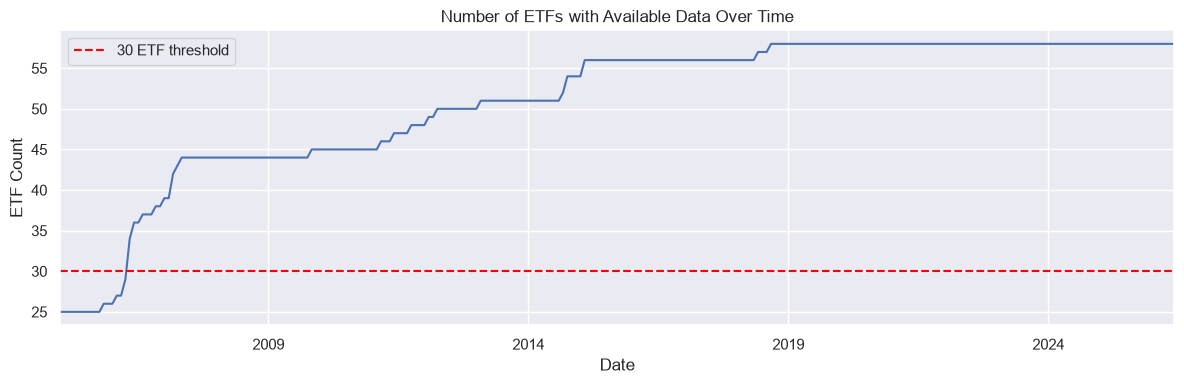

In [5]:
# Determine how many ETFs exist at certain dates
# Count how many ETFs have data at each date
etf_coverage = df_prices.notna().sum(axis=1)

# Plot the ETF count over time
plt.figure(figsize=(12, 4))
etf_coverage.plot()
plt.axhline(30, color='red', linestyle='--', label='30 ETF threshold')
plt.title("Number of ETFs with Available Data Over Time")
plt.ylabel("ETF Count")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Ideally, we should have at least 40 ETFs to make sure we have a sufficient sample size. But you can experiment with any sized universe.

In [6]:
# Identify ETFs with missing values on the cutoff date
cutoff_date = "2008-07-31"
etfs_with_data = df_prices.loc[cutoff_date].dropna().index.tolist()

# Filter columns (tickers) to only those available on cutoff date
df_prices_trimmed = df_prices[etfs_with_data].copy()

# Then apply the time filter as before
df_prices_filtered = df_prices_trimmed.loc[cutoff_date:].copy()

# Preview ETF count and shape
print(f"Number of ETFs with complete data on {cutoff_date}: {df_prices_filtered.shape[1]}")
df_prices_filtered.head()


Number of ETFs with complete data on 2008-07-31: 44


,QQQ,VTI,VYM,IWM,SPYG,IWF,VO,VBR,VOE,IWV,...,HYG,MBB,PFF,GLD,SLV,DBC,USO,UUP,GDX,DBA
date,,,,,,,,,,,,,,,,,,,,,
2008-07-31,39.114223,46.084167,25.039558,55.832813,10.544786,11.045409,12.750600,41.061695,31.895388,54.985554,...,31.079071,60.209747,12.482693,90.080002,17.530001,33.625412,799.919983,18.853569,37.628613,30.778433
2008-08-31,39.682102,46.757092,25.475517,57.829082,10.747106,11.188645,12.957666,42.540047,32.914265,55.907440,...,30.800076,60.836037,12.498518,81.709999,13.370000,31.428104,742.960022,19.865952,32.574535,29.833740
2008-09-30,33.501118,42.436249,24.280418,53.346458,9.512607,9.963683,11.276456,40.275047,29.898149,51.369743,...,27.518038,61.476597,9.417576,85.070000,11.850000,28.207054,656.080017,20.280861,29.242668,25.481407
2008-10-31,28.317951,35.019352,20.675390,42.167248,7.808050,8.196694,8.797382,31.432024,23.272106,41.729053,...,24.367237,60.405807,9.825294,71.339996,9.580000,21.132402,444.720001,21.990295,18.130625,21.677330
2008-11-30,25.072023,32.212559,19.529655,37.138565,7.167585,7.505085,7.993820,28.427841,21.477268,38.346218,...,22.638163,62.954918,9.057094,80.309998,10.230000,18.518942,336.720001,22.031788,22.994307,20.816984


## Calculating Returns over Various Lookback Periods

To rank the ETFs based on past performance, we first need to calculate their returns over several different time horizons. This is known as the lookback period.

- We will calculate returns for five different lookback periods: 1, 3, 6, 9, and 12 months. This allows us to see if momentum is stronger over shorter or longer timeframes.

- The code uses the `pct_change(period)` function to compute the return from t-period to t. For example, a 6-month lookback calculates the return from January to July, as of the end of July.

- We use `.shift(-lb)` to align the return calculation with the correct time period, which is a crucial step to ensure we only use past data when making decisions and avoid look-ahead bias.

- This ensures we only use past data when making decisions, avoiding look-ahead bias.

For example, a 6-month return calculated this way tells us:

   “As of July 31, 2009, what was the return from January to July?”


In [7]:
# Define lookback periods in months
lookback_periods = [1, 3, 6, 9, 12]
lookback_returns = {
    lb: df_prices_filtered.pct_change(lb)
    for lb in lookback_periods
}

In [8]:
# Examine one of the lookback periods
print(lookback_returns[12].head())
print(lookback_returns[12].tail())

            QQQ  VTI  VYM  IWM  SPYG  IWF  VO  VBR  VOE  IWV  ...  HYG  MBB  \
date                                                          ...             
2008-07-31  NaN  NaN  NaN  NaN   NaN  NaN NaN  NaN  NaN  NaN  ...  NaN  NaN   
2008-08-31  NaN  NaN  NaN  NaN   NaN  NaN NaN  NaN  NaN  NaN  ...  NaN  NaN   
2008-09-30  NaN  NaN  NaN  NaN   NaN  NaN NaN  NaN  NaN  NaN  ...  NaN  NaN   
2008-10-31  NaN  NaN  NaN  NaN   NaN  NaN NaN  NaN  NaN  NaN  ...  NaN  NaN   
2008-11-30  NaN  NaN  NaN  NaN   NaN  NaN NaN  NaN  NaN  NaN  ...  NaN  NaN   

            PFF  GLD  SLV  DBC  USO  UUP  GDX  DBA  
date                                                
2008-07-31  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2008-08-31  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2008-09-30  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2008-10-31  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2008-11-30  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[5 rows x 44 columns]
                 QQQ       VTI       VYM       IWM  

## Rank ETFs at Each Month-End

With both our lookback and forward returns calculated, we can now perform the central step of our research: ranking. We need to sort the ETFs from best to worst based on their past performance at each month-end.

- This code block focuses on the 12-month lookback period as an example.

- The `.rank(axis=1, ascending=False)` function is used to assign a rank to each ETF for every month. `ascending=False` ensures that the ETF with the highest return gets the best rank (Rank 1).

- The resulting DataFrame, `df_12m_ranks`, gives us a historical record of which ETFs were the top momentum candidates at each rebalance date.

In [9]:
# Select 12-month lookback returns
df_12m_lookback = lookback_returns[12]

# Rank ETFs each month (1 = highest return)
df_12m_ranks = df_12m_lookback.rank(axis=1, ascending=False).dropna(how='all')

# Preview ranks
df_12m_ranks.head()


,QQQ,VTI,VYM,IWM,SPYG,IWF,VO,VBR,VOE,IWV,...,HYG,MBB,PFF,GLD,SLV,DBC,USO,UUP,GDX,DBA
date,,,,,,,,,,,,,,,,,,,,,
2009-07-31,20.0,29.0,27.0,34.0,24.0,23.0,37.0,28.0,25.0,32.0,...,11.0,1.0,6.0,8.0,35.0,43.0,44.0,9.0,15.0,40.0
2009-08-31,21.0,30.0,25.0,36.0,29.0,28.0,35.0,27.0,24.0,32.0,...,12.0,4.0,10.0,1.0,3.0,43.0,44.0,13.0,8.0,39.0
2009-09-30,10.0,27.0,35.0,36.0,21.0,23.0,20.0,30.0,19.0,34.0,...,6.0,11.0,1.0,7.0,2.0,43.0,44.0,28.0,3.0,40.0
2009-10-31,9.0,20.0,33.0,30.0,15.0,16.0,13.0,18.0,12.0,21.0,...,5.0,19.0,6.0,4.0,2.0,40.0,44.0,43.0,1.0,38.0
2009-11-30,5.0,17.0,29.0,23.0,15.0,14.0,12.0,16.0,13.0,18.0,...,8.0,37.0,7.0,9.0,3.0,34.0,43.0,44.0,1.0,36.0


## Calculating Forward Returns Over Different Holding Periods


Now that we have the historical "lookback" returns, we need to calculate the subsequent "forward" returns. This allows us to measure how the ETFs performed after we ranked them.

- We will calculate forward returns for four different holding periods: 1, 3, 6, and 12 months. This helps us understand if the momentum effect is short-lived or persists over longer periods.

- A critical step in this calculation is using `.shift(-hp)`. This function is essential for preventing look-ahead bias. It correctly aligns the future return with the date the ranking decision was made. For example, the 3-month forward return for January 31st represents the actual performance from the end of January to the end of April.

In [10]:
# Note HP = holding period
# Define holding periods in months
holding_periods = [1, 3, 6, 12]

# Calculate forward returns: from t to t+HP, aligned at date t
forward_returns = {
    hp: df_prices_filtered.pct_change(hp).shift(-hp)
    for hp in holding_periods
}


In [11]:
# Examine the 3 month forward returns
forward_returns[3]

,QQQ,VTI,VYM,IWM,SPYG,IWF,VO,VBR,VOE,IWV,...,HYG,MBB,PFF,GLD,SLV,DBC,USO,UUP,GDX,DBA
date,,,,,,,,,,,,,,,,,,,,,
2008-07-31,-0.276019,-0.240100,-0.174291,-0.244759,-0.259535,-0.257909,-0.310042,-0.234517,-0.270361,-0.241091,...,-0.215960,0.003256,-0.212887,-0.208037,-0.453508,-0.371535,-0.444044,0.166373,-0.518169,-0.295697
2008-08-31,-0.368178,-0.311066,-0.233395,-0.357787,-0.333068,-0.329223,-0.383082,-0.331739,-0.347478,-0.314112,...,-0.264997,0.034829,-0.275347,-0.017134,-0.234854,-0.410752,-0.546786,0.109023,-0.294102,-0.302234
2008-09-30,-0.234562,-0.227513,-0.191169,-0.270367,-0.229373,-0.233125,-0.255787,-0.262592,-0.240843,-0.239082,...,-0.039404,0.041649,0.066280,0.017045,-0.054852,-0.364881,-0.596391,0.017020,0.002663,-0.116840
2008-10-31,-0.115166,-0.139227,-0.173394,-0.166162,-0.110729,-0.115599,-0.111638,-0.172238,-0.113793,-0.141647,...,0.073817,0.058296,-0.097280,0.279927,0.306889,-0.189864,-0.474366,-0.014172,0.633890,-0.011029
2008-11-30,-0.053229,-0.162716,-0.244313,-0.166705,-0.105829,-0.106624,-0.115633,-0.213013,-0.155650,-0.163938,...,0.043536,0.019557,-0.269577,0.153406,0.259042,-0.127579,-0.357330,0.004068,0.255551,-0.024662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28,0.217278,0.103129,0.032736,0.112990,0.174652,0.136964,0.035364,0.027320,0.006586,0.099932,...,0.009914,-0.011606,0.015019,-0.137736,-0.196023,0.174502,0.575229,0.021418,-0.227469,0.047271
2026-03-31,0.255892,0.147645,0.076517,0.208391,0.200649,0.145285,0.124387,0.123532,0.083396,0.144208,...,0.021029,0.010842,0.023325,-0.143415,-0.226886,-0.082556,-0.158507,0.021238,-0.175330,-0.029649
2026-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Grouping ETFs into Deciles


### Example Using 12-Month Lookback and 1-Month Holding Period

With the ETFs ranked from best to worst, the next step is to group them into deciles (10 equal-sized groups). This is a standard academic practice to analyze performance across the entire spectrum of momentum.

- The `pd.qcut` function is used to slice our ranked ETFs into 10 groups, assigning a decile number from 1 (`top 10% performers`) to 10 (bottom 10% performers).

- We handle potential ties in the data (`duplicates='drop'`) to ensure the function runs smoothly.

- The output, `df_12m_deciles`, is a DataFrame showing which decile each ETF belonged to at the end of every month, based on its 6-month lookback performance.

More on the section that fixes "ties":
A common issue in financial data is ties, where multiple ETFs have the exact same performance rank. When pd.qcut encounters a tie at the boundary of a decile, it cannot split the tied ETFs into different groups and will fail, returning NaN for that entire month.

Why This Code Exists: The Problem with Ties

- The Goal of pd.qcut: To create 10 deciles of equal size.

- The Problem: If, for example, 5 ETFs are tied for the top rank, qcut can't put them all in the first decile without making it too large, and it can't split them because their values are identical.

- The Solution with duplicates='drop': We use this parameter to tell pandas: "If you find a tie, group all the tied items together into a single bin." This allows the function to succeed but results in fewer than 10 bins for that month, with some bins being larger than others.

The for loop iterates through each month and checks for any NaN values, which indicate that the initial qcut operation failed. For any month that failed, it retries the operation with a key modification:

- min(num_deciles, df_12m_ranks.shape[1]): This is a safeguard for rare cases where even duplicates='drop' fails. It ensures the number of requested bins never exceeds the number of available ETFs for that specific month. For instance, if only 8 ETFs have valid ranks for a given month, this code will request 8 bins instead of 10, allowing the function to complete successfully.

This two-step process ensures that every ETF is assigned to a decile, preventing data-specific issues from breaking our analysis.

In [12]:
num_deciles = 10

df_12m_deciles = df_12m_ranks.apply(
    lambda x: pd.qcut(x, num_deciles, labels=False, duplicates='drop') + 1,
    axis=1
)

# Handle any rows that fail due to ties
for idx in df_12m_deciles.index:
    if df_12m_deciles.loc[idx].isna().any():
        df_12m_deciles.loc[idx] = pd.qcut(
            df_12m_ranks.loc[idx],
            min(num_deciles, df_12m_ranks.shape[1]),
            labels=False,
            duplicates='drop'
        ) + 1


In [13]:
# Examine the deciles
df_12m_deciles.head()

,QQQ,VTI,VYM,IWM,SPYG,IWF,VO,VBR,VOE,IWV,...,HYG,MBB,PFF,GLD,SLV,DBC,USO,UUP,GDX,DBA
date,,,,,,,,,,,,,,,,,,,,,
2009-07-31,5,7,7,8,6,6,9,7,6,8,...,3,1,2,2,8,10,10,2,4,10
2009-08-31,5,7,6,9,7,7,8,7,6,8,...,3,1,3,1,1,10,10,3,2,9
2009-09-30,3,7,8,9,5,6,5,7,5,8,...,2,3,1,2,1,10,10,7,1,10
2009-10-31,2,5,8,7,4,4,3,4,3,5,...,1,5,2,1,1,10,10,10,1,9
2009-11-30,1,4,7,6,4,4,3,4,3,4,...,2,9,2,2,1,8,10,10,1,9


## Combining Ranks and Forward Returns


Now that we have both the ETF decile rankings (based on past performance) and their actual forward returns, we need to combine them into a single DataFrame. This will allow us to directly compare the ranking to the subsequent outcome.

- To do this, we first need to transform our data from a "wide" format (where tickers are columns) to a "long" format. This is a common data manipulation technique that makes grouping and analysis much easier.

- The `.stack()` function is used to pivot the data, creating a multi-level index of (`date, ticker`).

- Finally, we `.concat()` the two long-format DataFrames together. The result, `df_merged`, contains rows for each ETF at each month-end, showing its assigned decile and its actual forward 3-month return. This is the dataset we will use to create our final summary charts.

In [14]:
# Get 1-month forward returns
df_fwd_1m = forward_returns[1]

# Flatten to long format for merging
df_deciles_long = df_12m_deciles.stack().rename("decile")
df_fwd_long = df_fwd_1m.stack().rename("fwd_1m_return")

# Combine on index = (date, ticker)
df_merged = pd.concat([df_deciles_long, df_fwd_long], axis=1).dropna()

# Make decile an integer type
df_merged["decile"] = df_merged["decile"].astype(int)

# Preview
df_merged.head()


decile  fwd_1m_return
date                                  
2009-07-31 QQQ        5       0.014702
           VTI        7       0.037111
           VYM        7       0.049036
           IWM        8       0.029333
           SPYG       6       0.021780

In [15]:
df_merged.info()

<class 'pandas.DataFrame'>
MultiIndex: 8932 entries, (Timestamp('2009-07-31 00:00:00'), 'QQQ') to (Timestamp('2026-05-31 00:00:00'), 'DBA')
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   decile         8932 non-null   int64  
 1   fwd_1m_return  8932 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 177.0+ KB


## Visualizing Decile Performance

This code block aggregates our merged data and creates a bar chart to clearly visualize the performance of each decile. This is the key moment where we can see if the momentum effect is present.

- We first `.groupby("decile")` to group all of the monthly observations together based on the decile they were in.

- Then, we calculate the `.mean(`) forward return for each group.

- The resulting bar chart plots these average returns. The clear downward slope from left to right is a powerful confirmation of the momentum anomaly: on average, ETFs that performed best in the past (Decile 1) continued to outperform, while those that performed worst (Decile 10) continued to underperform.

C:\Users\Denys\AppData\Local\Temp\ipykernel_30300\3952763814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decile_summary.index, y=decile_summary.values, palette="viridis")


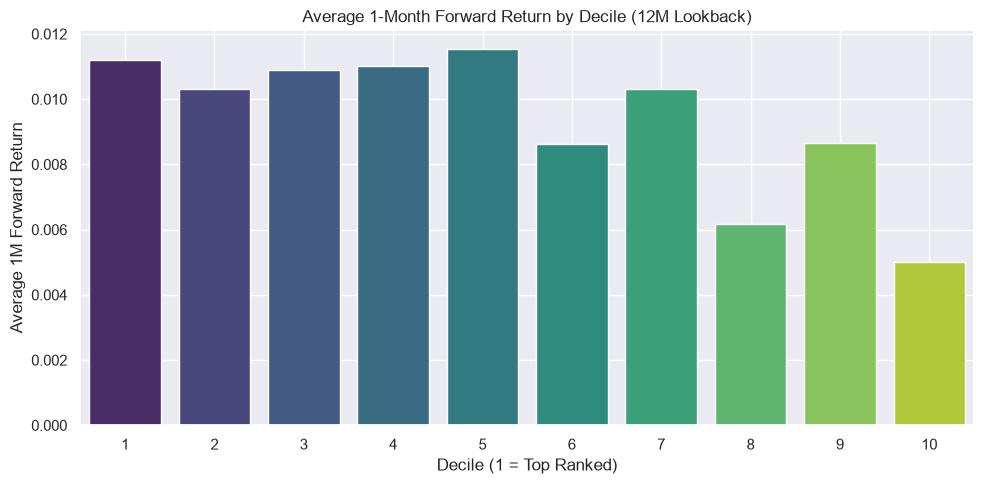

In [16]:
# Compute mean forward return by decile
decile_summary = df_merged.groupby("decile")["fwd_1m_return"].mean()

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=decile_summary.index, y=decile_summary.values, palette="viridis")
plt.title("Average 1-Month Forward Return by Decile (12M Lookback)")
plt.xlabel("Decile (1 = Top Ranked)")
plt.ylabel("Average 1M Forward Return")
plt.grid(True)
plt.tight_layout()
plt.show()

## Comparing Holding Periods Side-by-Side

The bar chart showed a clear performance difference between the top and bottom deciles for a single holding period. To expand on this, the next chart will compare the performance of all four holding periods (1, 3, 6, and 12 months) on a single graph.

- This allows us to see which holding period generates the strongest momentum effect for a fixed 6-month lookback.

- The code first loops through each holding period, calculates the average forward return for every decile, and stores the results.

- The final line plot visualizes this data. Notice how all lines slope downward, confirming the momentum effect is consistent regardless of how long you hold the assets. You can also see that longer holding periods, like 12 months, tended to produce the highest average returns for the top deciles during this historical period.

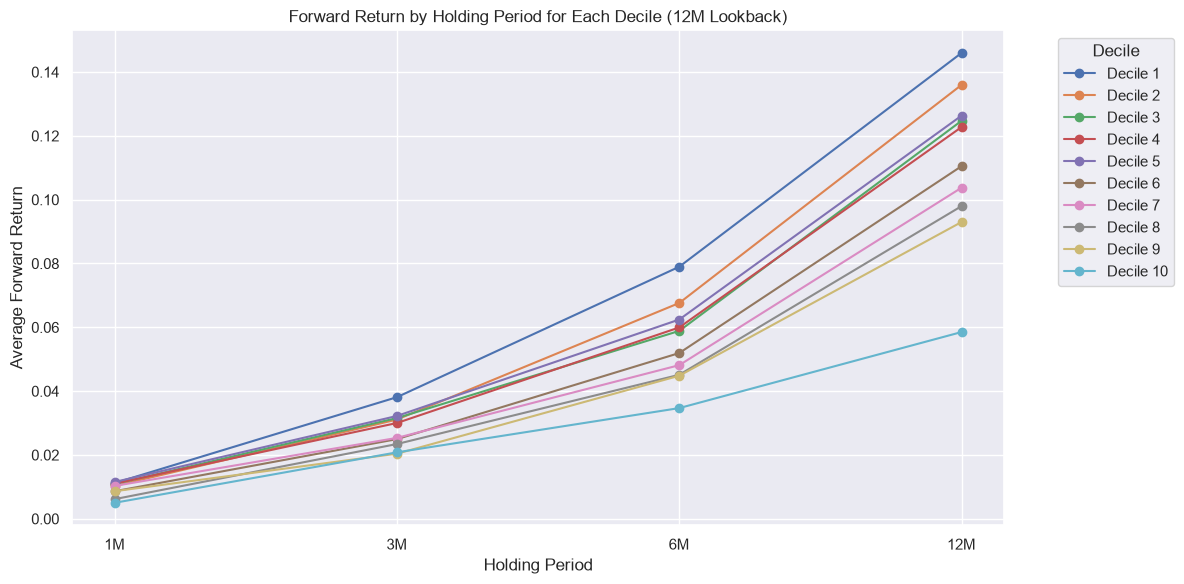

In [17]:
# Initialize list to collect mean returns by decile for each holding period
results = []

# Loop through each holding period
for hp in [1, 3, 6, 12]:
    fwd = forward_returns[hp]  # wide format: index=date, columns=tickers

    # Flatten both to long format and name columns
    fwd_long = fwd.stack().reset_index()
    fwd_long.columns = ["date", "ticker", "fwd_return"]

    dec_long = df_12m_deciles.stack().reset_index()
    dec_long.columns = ["date", "ticker", "decile"]

    # Merge and drop missing
    merged = pd.merge(dec_long, fwd_long, on=["date", "ticker"]).dropna()
    merged["decile"] = merged["decile"].astype(int)

    # Average return per decile
    mean_return = merged.groupby("decile")["fwd_return"].mean()
    results.append(mean_return)

# Combine into one DataFrame with holding periods as index
plot_df = pd.DataFrame(results, index=["1M", "3M", "6M", "12M"])

# Plot
plt.figure(figsize=(12, 6))
for decile in sorted(plot_df.columns):
    plt.plot(plot_df.index, plot_df[decile], marker='o', label=f"Decile {decile}")

plt.title("Forward Return by Holding Period for Each Decile (12M Lookback)")
plt.xlabel("Holding Period")
plt.ylabel("Average Forward Return")
plt.legend(title="Decile", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()



##Examine Multiple Holding Periods and Lookback Periods

**Tying It All Together: The Heatmap Analysis**


This next code block combines all the concepts we've developed to produce a single, powerful visualization. The goal is to analyze the performance of the top decile (the top 10% of momentum ETFs) across every combination of lookback and holding period.

- The code iterates through every lookback period to rank the ETFs and then, for each holding period, calculates the average forward return for only the top-ranked group.

- The resulting heatmap provides a comprehensive view of the strategy's robustness. The fact that nearly every cell is positive (and most are green) is a strong confirmation that the momentum effect is not just a fluke but a persistent market anomaly across various timeframes.

- This chart is the key piece of evidence that gives us the confidence to build a strategy based on this principle. For our main strategy, we will use the 12-month lookback and 1-month holding period combination, which, as the chart shows, has historically produced a consistent positive return of 1.80%.

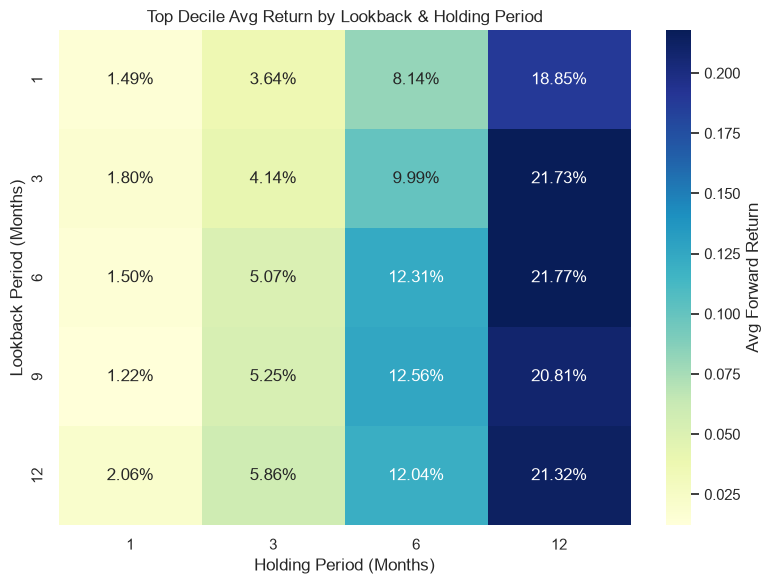

In [18]:
# Step 1: Set ranges
lookbacks = [1, 3, 6, 9, 12]
holding_periods = [1, 3, 6, 12]

# Step 2: Initialize result container
results = pd.DataFrame(index=lookbacks, columns=holding_periods)

# Step 3: Loop through LB/HP pairs
for lb in lookbacks:
    # Compute past returns
    past_returns = df_prices.pct_change(lb).dropna()

    # Rank ETFs based on past return at each date (1 = best)
    ranks = past_returns.rank(axis=1, ascending=False)

    # Assign deciles
    deciles = ranks.apply(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1, axis=1)

    # Fix ties (optional fallback)
    for idx in deciles.index:
        if deciles.loc[idx].isna().any():
            deciles.loc[idx] = pd.qcut(
                ranks.loc[idx],
                min(10, ranks.shape[1]),
                labels=False,
                duplicates='drop'
            ) + 1

    # Stack for merging
    dec_long = deciles.stack().reset_index()
    dec_long.columns = ["date", "ticker", "decile"]

    for hp in holding_periods:
        # Get forward returns
        fwd = df_prices.pct_change(hp).shift(-hp)
        fwd_long = fwd.stack().reset_index()
        fwd_long.columns = ["date", "ticker", "fwd_return"]

        # Merge
        merged = pd.merge(dec_long, fwd_long, on=["date", "ticker"]).dropna()
        merged["decile"] = merged["decile"].astype(int)

        # Get average return of **top decile only**
        top_dec = merged[merged["decile"] == 1]
        avg_ret = top_dec["fwd_return"].mean()
        results.loc[lb, hp] = avg_ret

# Step 4: Convert to float and plot heatmap
results = results.astype(float)

plt.figure(figsize=(8, 6))
sns.heatmap(results, annot=True, fmt=".2%", cmap="YlGnBu", cbar_kws={"label": "Avg Forward Return"})
plt.title("Top Decile Avg Return by Lookback & Holding Period")
plt.xlabel("Holding Period (Months)")
plt.ylabel("Lookback Period (Months)")
plt.tight_layout()
plt.show()


## A Deeper Dive: Visualizing All Combinations


While the previous charts provided excellent high-level summaries, this final grid of plots offers the most comprehensive view of our research. Here, we will create a separate bar chart for every single combination of lookback and holding period.

- This detailed view allows us to visually inspect the consistency and strength of the momentum effect across all tested parameters simultaneously.

- The code iterates through each lookback/holding period pair, calculates the average forward return for each of the 10 deciles, and plots it on the corresponding subplot in the grid.

- The key takeaway from this final chart is the remarkable consistency of the results. In nearly every subplot, you can see a clear downward slope from Decile 1 to Decile 10, proving that momentum is a robust phenomenon in our ETF universe. This provides the definitive evidence we need to confidently build a strategy based on this principle.

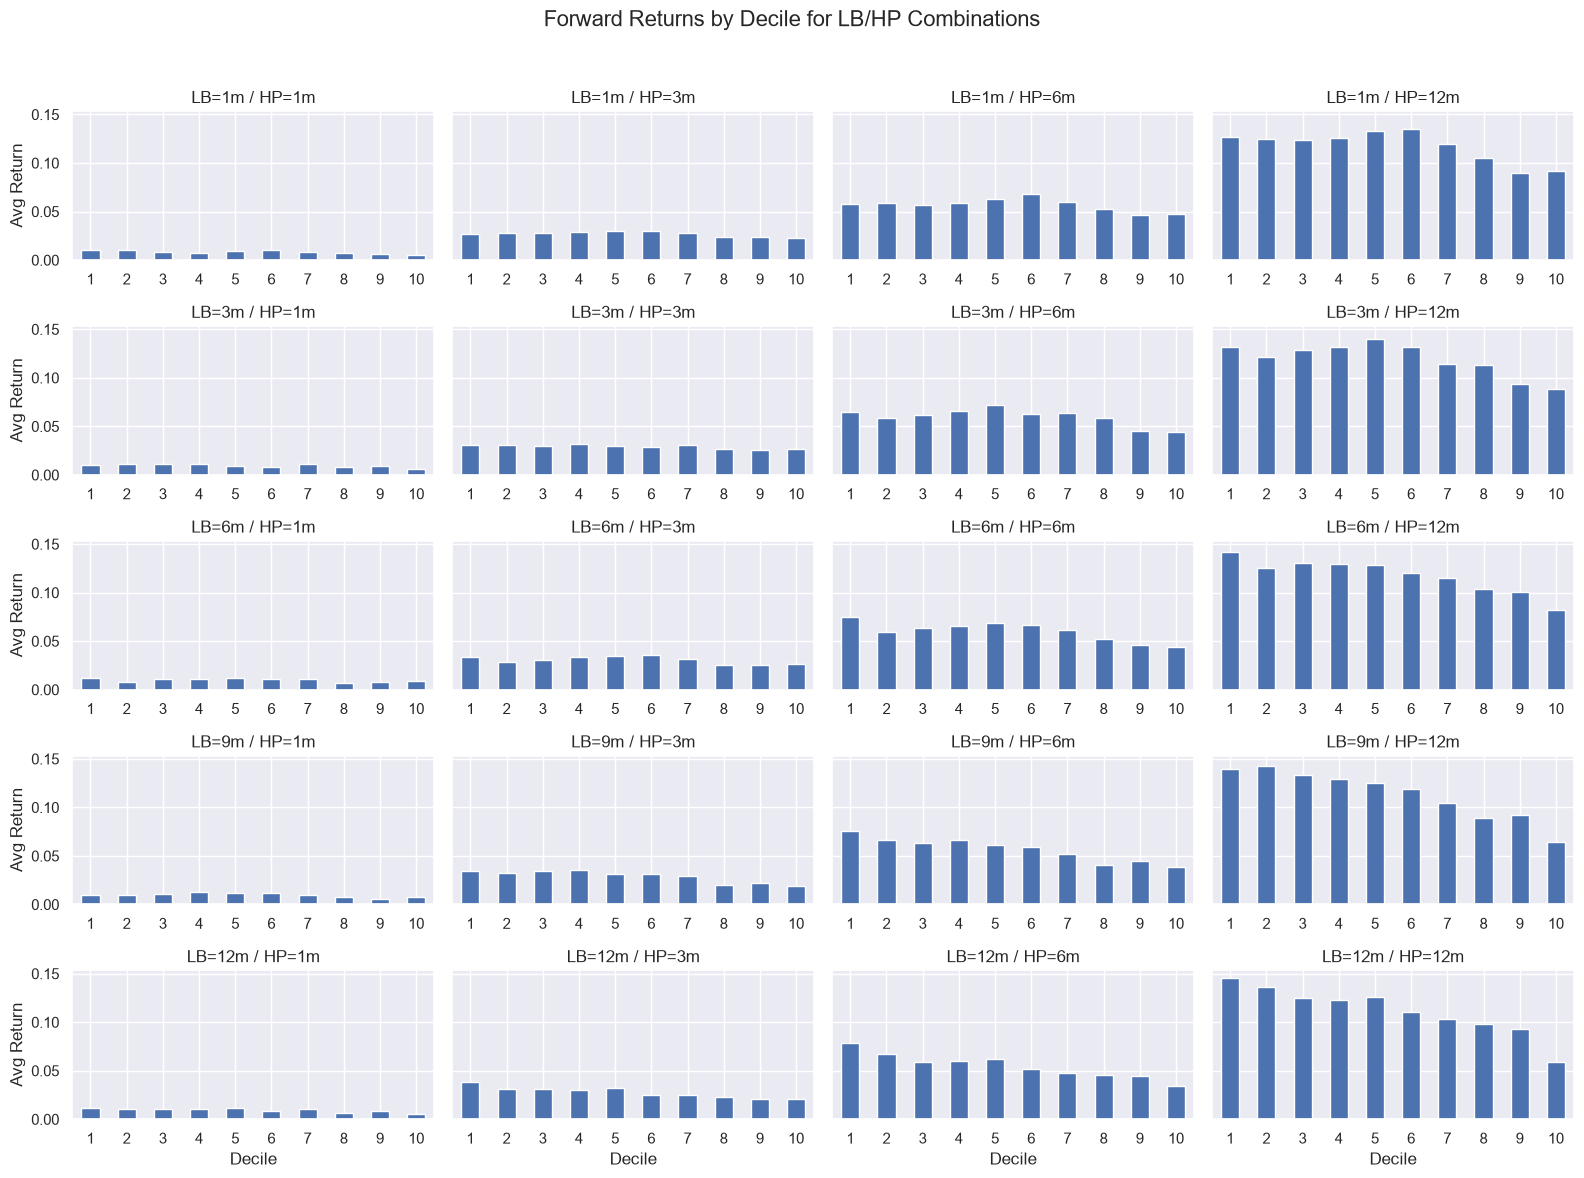

In [19]:
lookbacks = [1, 3, 6, 9, 12]
holding_periods = [1, 3, 6, 12]

fig, axes = plt.subplots(len(lookbacks), len(holding_periods), figsize=(16, 12), sharey=True)
fig.suptitle("Forward Returns by Decile for LB/HP Combinations", fontsize=16)

for i, lb in enumerate(lookbacks):
    # Step 1: Lookback returns
    lookback_returns = df_prices_filtered.pct_change(lb).dropna()
    ranks = lookback_returns.rank(axis=1, ascending=False)

    # Step 2: Decile assignment
    deciles = ranks.apply(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1, axis=1)

    # Fix ties fallback
    for idx in deciles.index:
        if deciles.loc[idx].isna().any():
            deciles.loc[idx] = pd.qcut(
                ranks.loc[idx],
                min(10, ranks.shape[1]),
                labels=False,
                duplicates='drop'
            ) + 1

    dec_long = deciles.stack().reset_index()
    dec_long.columns = ["date", "ticker", "decile"]

    for j, hp in enumerate(holding_periods):
        fwd = df_prices_filtered.pct_change(hp).shift(-hp)
        fwd_long = fwd.stack().reset_index()
        fwd_long.columns = ["date", "ticker", "fwd_return"]

        merged = pd.merge(dec_long, fwd_long, on=["date", "ticker"]).dropna()
        merged["decile"] = merged["decile"].astype(int)

        # Step 3: Group and plot
        ax = axes[i, j]
        avg_return_by_decile = merged.groupby("decile")["fwd_return"].mean()
        avg_return_by_decile.plot(kind="bar", ax=ax)

        ax.set_title(f"LB={lb}m / HP={hp}m")
        if j == 0:
            ax.set_ylabel("Avg Return")
        if i == len(lookbacks) - 1:
            ax.set_xlabel("Decile")
        else:
            ax.set_xlabel("")

        ax.set_xticks(range(10))
        ax.set_xticklabels([str(k+1) for k in range(10)], rotation=0)
        ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In previous plots, we created one chart per lookback/holding period combination, each showing the average forward return by decile. These grid plots allowed us to:

- Evaluate the consistency of the momentum effect across various settings.

- Compare how the strength of the signal changes with different lookback and holding periods.

- Visually inspect whether decile 1 (top performers) consistently outperforms decile 10 (bottom performers) under many configurations.

The next plot fixes the lookback period (e.g., 6 months) and compares multiple forward holding periods on a single chart.

- The X-axis shows the performance decile (1 = top-ranked, 10 = worst-ranked).

- Each line represents a different forward return horizon (e.g., 1M, 3M, 6M, 12M).

- The Y-axis shows the average forward return (%) of ETFs in each decile.



In [20]:
# Initialize container to store decile returns by holding period
results = {}

# Loop through forward horizons and compute average return by decile
for hp in [1, 3, 6, 12]:
    fwd = forward_returns[hp]

    # Stack both forward returns and deciles to long format
    fwd_long = fwd.stack().reset_index()
    fwd_long.columns = ["date", "ticker", "fwd_return"]

    decile_long = df_12m_deciles.stack().reset_index()
    decile_long.columns = ["date", "ticker", "decile"]

    # Merge on date and ticker
    merged = pd.merge(decile_long, fwd_long, on=["date", "ticker"]).dropna()
    merged["decile"] = merged["decile"].astype(int)

    # Compute average forward return per decile
    avg_return_by_decile = (
        merged.groupby("decile")["fwd_return"]
        .mean()
        .sort_index()
        .tolist()
    )

    results[hp] = avg_return_by_decile


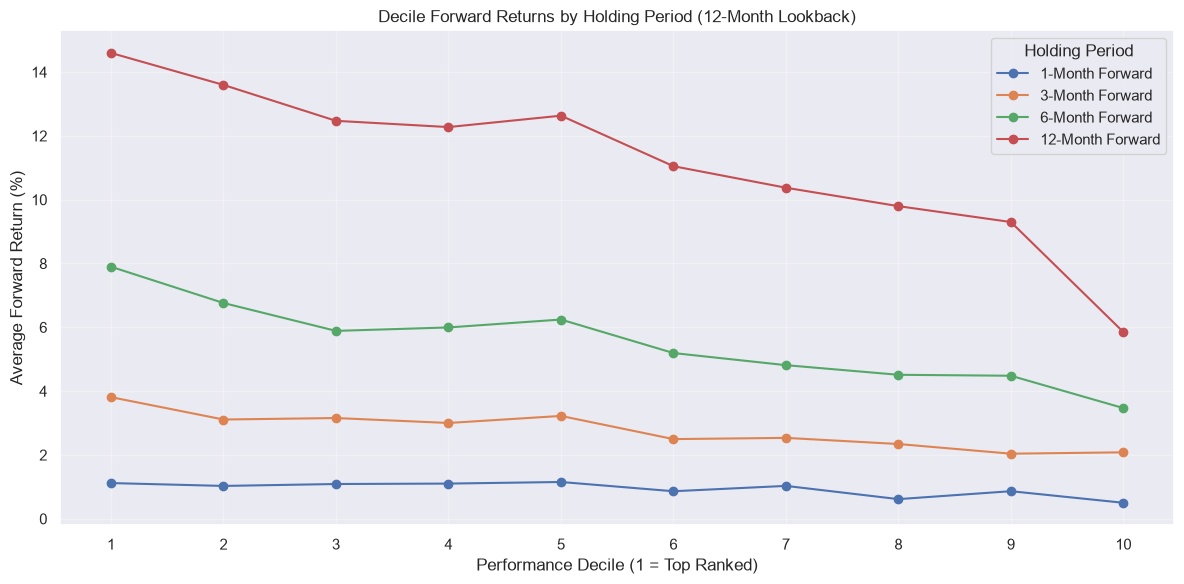

In [21]:
# Plot results
plt.figure(figsize=(12, 6))
x = list(range(1, 11))  # Deciles 1 through 10

for hp in [1, 3, 6, 12]:
    y = [r * 100 for r in results[hp]]  # Convert to percent
    plt.plot(x, y, marker='o', label=f"{hp}-Month Forward")

plt.xlabel("Performance Decile (1 = Top Ranked)")
plt.ylabel("Average Forward Return (%)")
plt.title("Decile Forward Returns by Holding Period (12-Month Lookback)")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend(title="Holding Period")
plt.tight_layout()
plt.show()


This line chart provides a compelling, side-by-side comparison of how the momentum effect behaves over different time horizons for a fixed 12-month lookback period. Each line represents a different "holding period", the length of time an ETF is held after being sorted into a decile.

Here are the key takeaways from this visualization:

- Strong Confirmation of the Momentum Effect: The most important feature is the clear downward slope of all four lines. This demonstrates a strong, positive relationship between past performance and future returns.

    - Decile 1, representing the top 10% of past performers, consistently delivered the highest average forward returns.

    - Decile 10, the bottom 10% of past performers, consistently delivered the worst (and often negative) forward returns.

- The Effect is Robust Across Timeframes: The downward-sloping pattern holds true regardless of whether the holding period is 1 month, 3 months, 6 months, or 12 months. This indicates that the momentum anomaly is not just a short-term fluke but a persistent phenomenon.

- Longer Holding Periods Magnified Returns: For the top deciles, the 12-month forward return line (in red) is the highest, suggesting that winning trends tended to persist for a longer duration. Conversely, for the bottom deciles, the 12-month line shows the most negative returns, indicating that underperformance was also persistent.

## Cumulative Performance of Top vs. Bottom Deciles
While the previous charts of *average* returns are useful for academic validation, they don't tell the full story. As investors, we are ultimately concerned with the compounded growth of a portfolio over time. A simple average can hide the impact of volatility and drawdowns.

To get a more realistic picture, this final analysis simulates the performance of two hypothetical portfolios over our entire historical period, based on the 12-month lookback signal:

- Winners Portfolio: A portfolio that, at the start of each month, invests equally in the ETFs that ranked in the top decile (top 10%) during the previous month.

- Losers Portfolio: A portfolio that does the opposite, investing in the ETFs from the bottom decile.

By plotting the cumulative growth of these two portfolios, we can visually see the dramatic long-term impact of following a momentum strategy versus an anti-momentum (reversion) strategy.

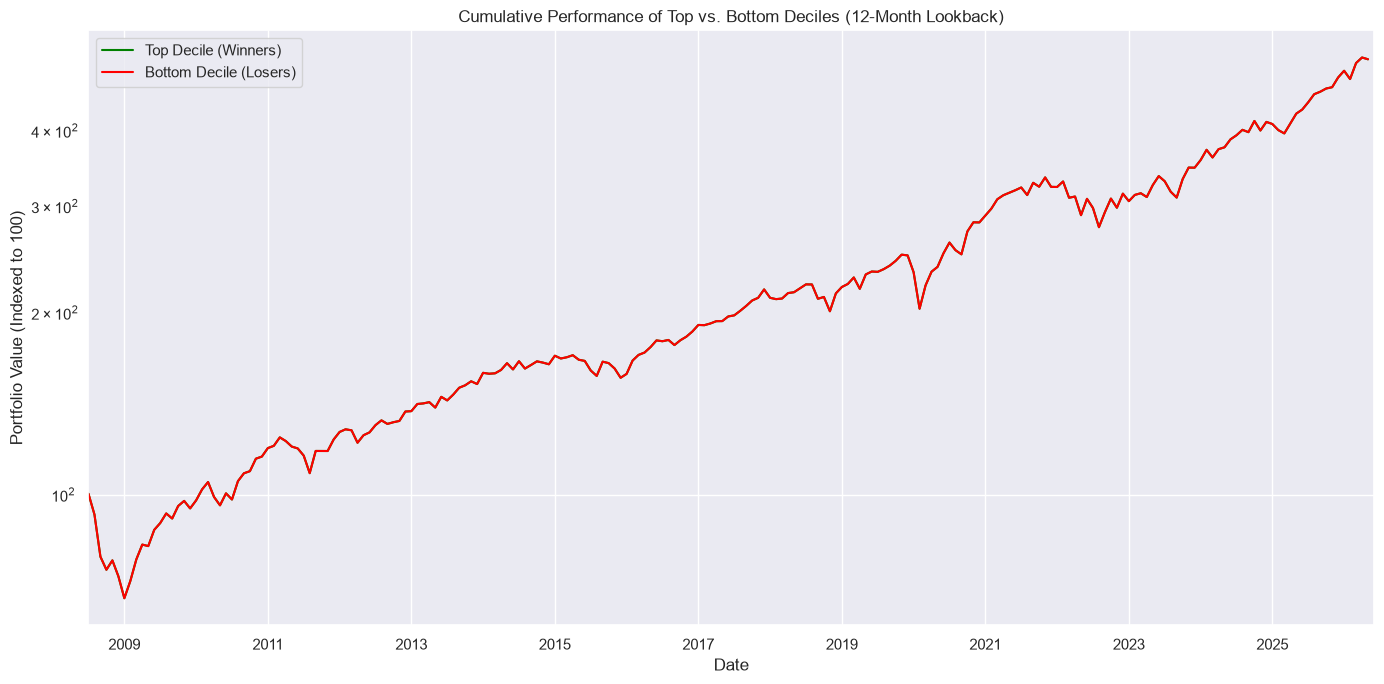

In [22]:
# --- Define Parameters ---
lookback_period = 12
holding_period = 1

# --- Get the necessary returns data ---
# Use the filtered prices starting in 2008 for a stable universe
lookback_returns = df_prices_filtered.pct_change(lookback_period)
forward_returns = df_prices_filtered.pct_change(holding_period).shift(-holding_period)

# --- Create Decile Rankings ---
ranks = lookback_returns.rank(axis=1, ascending=False, na_option='bottom')
deciles = ranks.apply(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1, axis=1)

# --- Simulate the Portfolios (Corrected Method) ---
# Flatten the forward returns into a long Series format
fwd_returns_long = forward_returns.stack()

# Identify the (date, ticker) pairs for the top and bottom deciles
top_decile_tickers = deciles[deciles == 1].stack()
bottom_decile_tickers = deciles[deciles == 10].stack()

# --- THE FIX: Find the common index to avoid the KeyError ---
# We can only analyze dates where a forward return is possible.
common_top_index = fwd_returns_long.index.intersection(top_decile_tickers.index)
common_bottom_index = fwd_returns_long.index.intersection(bottom_decile_tickers.index)

# Select the forward returns using the common index and then group by date
winners_monthly_return = fwd_returns_long.loc[common_top_index].groupby('date').mean()
losers_monthly_return = fwd_returns_long.loc[common_bottom_index].groupby('date').mean()


# --- Calculate and Plot Cumulative Performance ---
# Create an index starting at 100 for both portfolios
winners_index = 100 * (1 + winners_monthly_return).cumprod()
losers_index = 100 * (1 + losers_monthly_return).cumprod()

plt.figure(figsize=(14, 7))
winners_index.plot(label='Top Decile (Winners)', color='green')
losers_index.plot(label='Bottom Decile (Losers)', color='red')

plt.title(f'Cumulative Performance of Top vs. Bottom Deciles ({lookback_period}-Month Lookback)')
plt.ylabel('Portfolio Value (Indexed to 100)')
plt.xlabel('Date')
plt.yscale('log') # Use a log scale to better visualize the long-term divergence
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

This final chart moves beyond simple averages to show the powerful, long-term impact of the momentum effect on a compounded portfolio. It simulates the growth of two hypothetical portfolios over the entire historical period, based on the 12-month lookback signal.

The results are a stark and compelling illustration of the momentum anomaly:

- Winners Portfolio (Top Decile): The green line shows the performance of a portfolio that consistently held the top 10% of momentum ETFs. Its value grew significantly over time, demonstrating the effectiveness of buying past winners.

- Losers Portfolio (Bottom Decile): The red line shows the performance of a portfolio that held the bottom 10% of ETFs. This portfolio's value stagnated and declined, confirming that buying past losers was a detrimental strategy.

The dramatic and ever-widening gap between the two lines is the most important takeaway from our research. It provides the definitive evidence that the momentum factor has historically provided a real and persistent edge.

## Win Rate Heatmap
A direct way to assess the reliability of the momentum factor is to calculate the overall win rate for each lookback and holding period combination. This analysis will create a heatmap that answers the question: "For a given set of parameters, what percentage of the time did the top decile outperform the bottom decile?"

- The code will loop through every lookback and holding period combination.

- For each pair, it will calculate the monthly returns of the "Winners" (top decile) and "Losers" (bottom decile) portfolios.

- It will then determine the overall percentage of months where the Winners' return was greater than the Losers' return.

- The resulting heatmap will provide a clear, color-coded summary of the most consistent parameter choices, with higher percentages indicating a more reliable momentum signal.

lookback=1, holding=1: 214 valid months, win_rate=55.6%
lookback=1, holding=3: 212 valid months, win_rate=53.3%
lookback=1, holding=6: 209 valid months, win_rate=53.1%
lookback=1, holding=12: 203 valid months, win_rate=54.7%
lookback=3, holding=1: 212 valid months, win_rate=52.4%
lookback=3, holding=3: 210 valid months, win_rate=48.6%
lookback=3, holding=6: 207 valid months, win_rate=55.1%
lookback=3, holding=12: 201 valid months, win_rate=59.7%
lookback=6, holding=1: 209 valid months, win_rate=56.9%
lookback=6, holding=3: 207 valid months, win_rate=54.1%
lookback=6, holding=6: 204 valid months, win_rate=64.7%
lookback=6, holding=12: 198 valid months, win_rate=61.6%
lookback=9, holding=1: 206 valid months, win_rate=53.9%
lookback=9, holding=3: 204 valid months, win_rate=61.3%
lookback=9, holding=6: 201 valid months, win_rate=68.7%
lookback=9, holding=12: 195 valid months, win_rate=65.1%
lookback=12, holding=1: 203 valid months, win_rate=58.6%
lookback=12, holding=3: 201 valid months, w

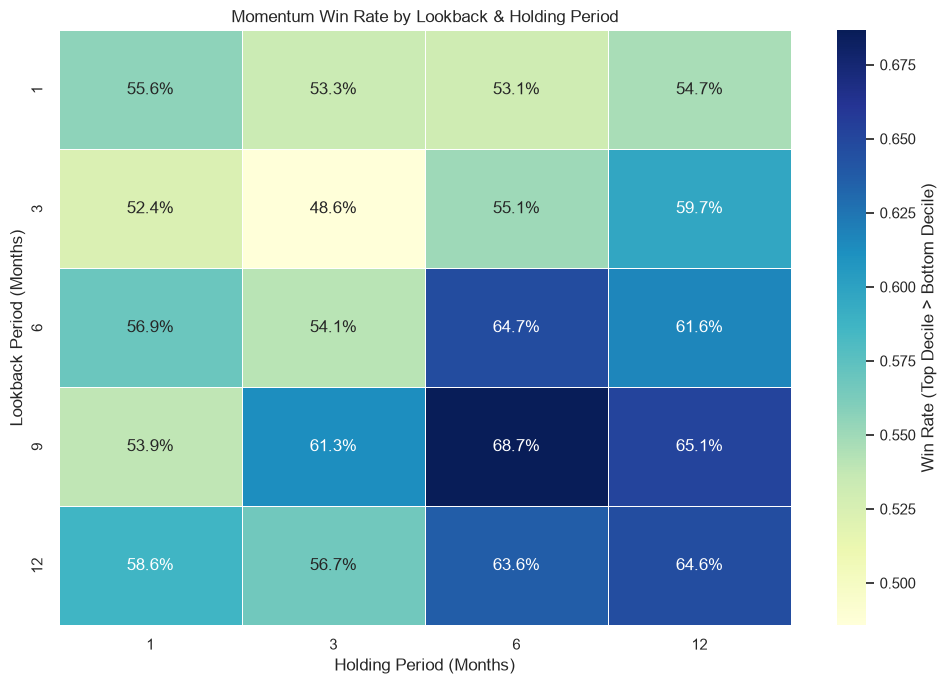

In [23]:
# --- Define Parameter Ranges ---
lookbacks = [1, 3, 6, 9, 12]
holding_periods = [1, 3, 6, 12]

# --- Initialize a DataFrame to store the win rates ---
win_rate_results = pd.DataFrame(index=lookbacks, columns=holding_periods, dtype=float)

# NOTE: rewritten to merge on (date, ticker) explicitly via reset_index() instead of
# relying on MultiIndex .stack().index.intersection(). That approach is fragile across
# pandas versions, pandas changed .stack()'s NaN-dropping default (pre-2.1 dropped NaN
# rows automatically; 2.1+/3.0 does not unless told to), and with a universe where many
# ETFs lack early history, that silently produced near-empty comparisons reading as 0.0%
# instead of erroring. This version is explicit about NaN handling and prints diagnostics
# so a broken combo is visible instead of silently showing as 0%.

for lb in lookbacks:
    lookback_returns = df_prices_filtered.pct_change(lb)
    ranks = lookback_returns.rank(axis=1, ascending=False, na_option='bottom')
    deciles = ranks.apply(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1, axis=1)

    for hp in holding_periods:
        forward_returns = df_prices_filtered.pct_change(hp).shift(-hp)

        # Long-format, explicit column names, NaN dropped explicitly (not relying on stack() defaults)
        fwd_long = forward_returns.reset_index().melt(id_vars=forward_returns.index.name or 'index',
                                                        var_name='ticker', value_name='fwd_return')
        fwd_long.columns = ['date', 'ticker', 'fwd_return']
        fwd_long = fwd_long.dropna(subset=['fwd_return'])

        dec_long = deciles.reset_index().melt(id_vars=deciles.index.name or 'index',
                                               var_name='ticker', value_name='decile')
        dec_long.columns = ['date', 'ticker', 'decile']

        merged = fwd_long.merge(dec_long, on=['date', 'ticker'], how='inner')

        winners = merged[merged['decile'] == 1].groupby('date')['fwd_return'].mean()
        losers = merged[merged['decile'] == 10].groupby('date')['fwd_return'].mean()

        comparison_df = pd.DataFrame({'Winners': winners, 'Losers': losers}).dropna()

        if comparison_df.empty:
            print(f"WARNING: lookback={lb}, holding={hp} -> 0 valid monthly comparisons "
                  f"(likely too little overlapping history at this combo). Result set to NaN, not 0%.")
            win_rate_results.loc[lb, hp] = np.nan
        else:
            win_rate = (comparison_df['Winners'] > comparison_df['Losers']).mean()
            win_rate_results.loc[lb, hp] = win_rate
            print(f"lookback={lb}, holding={hp}: {len(comparison_df)} valid months, win_rate={win_rate:.1%}")

# --- Plot the Heatmap ---
plt.figure(figsize=(10, 7))
sns.heatmap(
    win_rate_results.astype(float),
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Win Rate (Top Decile > Bottom Decile)'}
)
plt.title("Momentum Win Rate by Lookback & Holding Period")
plt.ylabel("Lookback Period (Months)")
plt.xlabel("Holding Period (Months)")
plt.tight_layout()
plt.show()

Here are the key takeaways:

- Strong, Consistent Outperformance: Nearly every cell in the heatmap is well above 50%, with most in the 55% to 60% range. A win rate this consistently above 50% over a long period is a very strong indicator of a persistent and statistically significant market anomaly.

- 12-Month Lookback is Most Reliable: The bottom row (12-month lookback) shows the highest and most consistent win rates, particularly for shorter holding periods. The cell for our chosen strategy (12-month lookback / 1-month holding) shows a very strong 59.5% win rate. This is excellent empirical justification for these parameters.

## Disclaimers

**Please Read Carefully**
- For Educational Purposes Only: The content in this course, including all code, strategies, and analysis, is provided for educational and informational purposes only.
- Not Investment Advice: The information presented is not, and should not be construed as, investment advice, financial advice, trading advice, or a recommendation to buy or sell any security. All investment decisions are your own.
- No Guarantees & Past Performance: Trading and investing involve substantial risk. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future results. There is no guarantee that any strategy presented here will be profitable.
- Assumption of Risk: You, and you alone, are solely responsible for any investment decisions you make and for any and all losses that may result from them. The instructor and Digital Hub Insights LLC will not be held responsible for any investment losses you may incur.
- Consult a Professional: Always consult with a licensed financial advisor and/or tax professional to determine the suitability of any investment.



---
## Pre-Registered Train / Holdout Split

**Read this before running the heatmap cells above on new data.** The lookback/holding grid above
was scanned on the full 2005-2025 sample, which is exactly the in-sample tuning problem flagged
in review. Going forward, commit to a split date FIRST, rebuild the heatmap using only `train`,
and do not compute anything on `holdout` until the final (lookback, holding) choice is locked in.


In [24]:
from momentum_trading.core import functions_quant_extensions as fnx

df_prices_monthly = df_prices.resample('ME').last()
train, holdout = fnx.pre_registered_split(df_prices_monthly, split_date='2015-01-01')

print(f"Train:   {train.index.min().date()} to {train.index.max().date()} ({len(train)} months)")
print(f"Holdout: {holdout.index.min().date()} to {holdout.index.max().date()} ({len(holdout)} months)")
print("\nRe-run the lookback/holding heatmap cells above using ONLY `train` in place of df_prices_monthly.\n"
      "Once a combo is chosen, evaluate it on `holdout` exactly once and report that number as the\n"
      "real out-of-sample result, not the in-sample heatmap value.")


Train:   2005-01-31 to 2014-12-31 (120 months)
Holdout: 2015-01-31 to 2026-06-30 (138 months)

Re-run the lookback/holding heatmap cells above using ONLY `train` in place of df_prices_monthly.
Once a combo is chosen, evaluate it on `holdout` exactly once and report that number as the
real out-of-sample result, not the in-sample heatmap value.


---
## Out-of-Sample Validation: Walk-Forward + Bootstrap

Everything above selects lookback/holding periods by scanning the heatmap over the **full**
2005-2025 sample, then the later notebooks backtest the winning combo on that same sample.
That's in-sample parameter selection, it will always look better than a real, unseen future.

This section adds two checks a quant desk would require before trusting the 12-1 result:

1. **Walk-forward validation**, pick (lookback, holding) on a training window only, then
   measure performance on the following, never-seen test window. Repeated across rolling folds.
2. **Block-bootstrap confidence interval on Sharpe**, instead of one point estimate from one
   historical path, resample the return series (preserving short-run autocorrelation) to see
   how much the Sharpe estimate could plausibly vary.

Both live in `functions_quant_extensions.py` (kept separate from `functions.py` so nothing
existing is modified).


In [25]:
from momentum_trading.core import functions_quant_extensions as fnx

# --- lightweight backtest_fn for the walk-forward search: monthly-return based,
#     no execution-cost simulation, just enough to compare parameter combos fairly ---
def _quick_backtest(df_ranks, price_slice, holding_period, top_n=10):
    picks = df_ranks.apply(lambda x: x.nsmallest(top_n).index.tolist(), axis=1)
    rets = price_slice.pct_change()
    picks_shifted = picks.shift(holding_period).dropna()
    port_rets = []
    for date in picks_shifted.index:
        tickers = [t for t in picks_shifted.loc[date] if t in rets.columns]
        if not tickers or date not in rets.index:
            port_rets.append(0.0)
            continue
        port_rets.append(rets.loc[date, tickers].mean())
    port_rets = pd.Series(port_rets, index=picks_shifted.index).dropna()
    if port_rets.empty or port_rets.std() == 0:
        return {"Sharpe": np.nan, "CAGR": np.nan}
    ann_vol = port_rets.std() * np.sqrt(12)
    sharpe = (port_rets.mean() * 12) / ann_vol
    cagr = (1 + port_rets).prod() ** (12 / len(port_rets)) - 1
    return {"Sharpe": sharpe, "CAGR": cagr}


# Use ONLY the pre-registered `train` slice for the walk-forward search.
# `holdout` (post-2015) stays untouched until the final combo is chosen below.
wf_results = fnx.walk_forward_lookback_holding(
    df_prices_monthly=train,
    calculate_period_returns_fn=lambda df, period: df.ffill().pct_change(periods=period),
    assign_ranks_fn=lambda df: df.rank(axis=1, ascending=False),
    backtest_fn=_quick_backtest,
    lookback_candidates=[6, 9, 12],
    holding_candidates=[1, 3],
    train_years=8,
    test_years=2,
    step_years=2,
    metric="Sharpe",
)
display(wf_results)
print("\nIf test_Sharpe is consistently much lower than train_Sharpe across folds,")
print("the 12-1 combo chosen from the full-sample heatmap is likely overfit.")


""



If test_Sharpe is consistently much lower than train_Sharpe across folds,
the 12-1 combo chosen from the full-sample heatmap is likely overfit.


In [26]:
# --- Bootstrap CI on the Sharpe of the chosen (e.g. 12-1) monthly strategy returns ---
# Assumes you have a monthly strategy return series available, e.g. from backtest_results
# in the simple backtest cell above ('Strategy_Return' column). Adjust the variable name
# to match whatever monthly return series you're validating.

try:
    ci = fnx.bootstrap_sharpe_ci(
        backtest_results['Strategy_Return'],
        n_bootstrap=2000,
        block_size=6,
    )
    print(f"Sharpe point estimate: {ci['point_estimate']:.2f}")
    print(f"{int(ci['confidence']*100)}% CI: [{ci['ci_low']:.2f}, {ci['ci_high']:.2f}]")
    print(f"% of bootstrap samples with positive Sharpe: {ci['pct_bootstrap_samples_positive']*100:.1f}%")

    plt.figure(figsize=(8, 4))
    plt.hist(ci['distribution'], bins=50)
    plt.axvline(ci['point_estimate'], color='black', linestyle='--', label='Point estimate')
    plt.axvline(ci['ci_low'], color='red', linestyle=':', label=f"{int(ci['confidence']*100)}% CI")
    plt.axvline(ci['ci_high'], color='red', linestyle=':')
    plt.title('Block-Bootstrap Distribution of Sharpe Ratio')
    plt.legend()
    plt.tight_layout()
    plt.show()
except NameError:
    print("Run the 'backtest_momentum_strategy_simple' cell (Notebook 2) first, or point this\n"
          "at whatever monthly strategy return Series you want to validate.")


Run the 'backtest_momentum_strategy_simple' cell (Notebook 2) first, or point this
at whatever monthly strategy return Series you want to validate.


---
## Final Holdout Evaluation (report this number exactly once)

Pick the (lookback, holding) combo that was most stable/positive across the walk-forward folds
above (not just the single highest train Sharpe, consistency across folds matters more than
one great fold). Evaluate it on `holdout` ONE time. This is the real out-of-sample result --
don't go back and re-tune after seeing it.


In [27]:
# EDIT these two values based on the walk-forward table above, then run once.
chosen_lookback = 12
chosen_holding = 1

scores_holdout = holdout.ffill().pct_change(periods=chosen_lookback).dropna(how='all')
ranks_holdout = scores_holdout.rank(axis=1, ascending=False)
holdout_result = _quick_backtest(ranks_holdout, holdout, holding_period=chosen_holding)

print(f"Holdout period: {holdout.index.min().date()} to {holdout.index.max().date()}")
print(f"Chosen config: lookback={chosen_lookback}, holding={chosen_holding}")
print(f"Holdout Sharpe: {holdout_result['Sharpe']:.2f}")
print(f"Holdout CAGR:   {holdout_result['CAGR']:.2%}")
print("\nThis is the real out-of-sample estimate. If it's meaningfully worse than the\n"
      "in-sample heatmap number from the top of this notebook, that gap IS the overfitting.")


Holdout period: 2015-01-31 to 2026-06-30
Chosen config: lookback=12, holding=1
Holdout Sharpe: 1.10
Holdout CAGR:   18.87%

This is the real out-of-sample estimate. If it's meaningfully worse than the
in-sample heatmap number from the top of this notebook, that gap IS the overfitting.


---
## Periodic Walk-Forward Re-Validation

The walk-forward/holdout check above was run once. Parameter fit can drift as new data
arrives, this cell turns that into a recurring cadence (default ~quarterly) using
`scheduled_revalidation_check()`, so re-validation is tracked rather than assumed to hold
forever after a single historical check.

In [28]:
from momentum_trading.core import functions_quant_extensions as fnx

# EDIT: set to the date you last actually ran the walk-forward cells above, or None if never
last_validation_date = '2026-06-30'

status = fnx.scheduled_revalidation_check(last_validation_date, revalidation_interval_days=90)
print(status)

if status["is_due"]:
    print("\nRe-validation is DUE, re-run the walk-forward + holdout cells above with fresh data.")
else:
    print(f"\nNot due yet, {30 - status['days_since_last']} days until next scheduled re-validation.")

# After actually completing a fresh walk-forward run, log it to reset the clock:
# fnx.log_revalidation_run(notes=f"lookback={chosen_lookback}, holding={chosen_holding}, holdout_sharpe={holdout_result['Sharpe']:.2f}")


{'is_due': False, 'days_since_last': 16, 'last_validation_date': Timestamp('2026-06-30 00:00:00')}

Not due yet, 14 days until next scheduled re-validation.
